In [1]:
import intake
cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['UK']

In [2]:
import easygems.healpix as egh

/home/users/mmuetz/miniforge3/envs/hackathon_base_env/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
list(cat)

['CERES_EBAF',
 'ERA5',
 'IR_IMERG',
 'JRA3Q',
 'MERRA2',
 'arp-gem-1p3km',
 'arp-gem-2p6km',
 'casesm2_10km_nocumulus',
 'icon_d3hp003',
 'icon_d3hp003aug',
 'icon_d3hp003feb',
 'icon_ngc4008',
 'ifs_tco3999-ng5_deepoff',
 'ifs_tco3999-ng5_rcbmf',
 'ifs_tco3999-ng5_rcbmf_cf',
 'ifs_tco3999_rcbmf',
 'nicam_220m_test',
 'nicam_gl11',
 'scream-dkrz',
 'tracking-d3hp003',
 'um_Africa_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SEA_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_glm_n1280_CoMA9_TBv1p2',
 'um_glm_n1280_GAL9',
 'um_glm_n2560_RAL3p3']

In [4]:
ds = cat['um_Africa_km4p4_RAL3P3_n1280_GAL9_nest'](zoom=8, time='PT3H').to_dask()

/home/users/mmuetz/miniforge3/envs/hackathon_base_env/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [5]:
ds

<xarray.Dataset> Size: 2TB
Dimensions:   (cell: 393216, time: 3497, pressure: 25)
Coordinates:
  * cell      (cell) int64 3MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
    crs       float64 8B ...
  * pressure  (pressure) int64 200B 1 5 10 20 30 50 ... 875 900 925 950 975 1000
  * time      (time) datetime64[ns] 28kB 2020-01-20 ... 2021-04-01
Data variables: (12/13)
    cli       (time, pressure, cell) float32 138GB ...
    clw       (time, pressure, cell) float32 138GB ...
    hur       (time, pressure, cell) float32 138GB ...
    hus       (time, pressure, cell) float32 138GB ...
    qg        (time, pressure, cell) float32 138GB ...
    qr        (time, pressure, cell) float32 138GB ...
    ...        ...
    ta        (time, pressure, cell) float32 138GB ...
    ua        (time, pressure, cell) float32 138GB ...
    va        (time, pressure, cell) float32 138GB ...
    wa        (time, pressure, cell) float32 138GB ...
    weights   (pressure, cell) float32 39MB ...
    zg        (time, pressure, cell) float32 138GB ...
Attributes:
    Met Office DYAMOND3 simulations:  A group of experiments have been conduc...
    bounds:                           {'lower_left_lat': -40.0, 'lower_left_l...
    latitiude_convention:             [-90, 90]
    longitude_convention:             [0, 360]
    regional:                         True
    simulation:                       Africa_km4p4_RAL3P3.n1280_GAL9_nest

In [7]:
ds = ds.pipe(egh.attach_coords)

In [10]:
(ds.lon.values == 0).sum()

np.int64(256)

<Figure size 640x480 with 0 Axes>

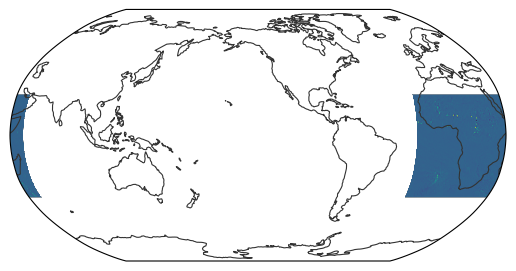

In [16]:
egh.healpix_show(ds.wa.sel(pressure=500).sel(time='2020-07-01 00:00'))